In [1]:
from tribev2.tribev2 import TribeModel
from tribev2.tribev2.plotting import PlotBrain

/root/amd-developer-hackathon/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/amd-developer-hackathon/venv/lib/python3.12/site-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-05-07 01:39:15 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


In [3]:
model = TribeModel.from_pretrained("facebook/tribev2", cache_folder="./cache")
plotter = PlotBrain(mesh="fsaverage5")

2026-05-07 01:39:41 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt


In [4]:
df = model.get_events_dataframe(video_path="data/titanic_trailer_04.mp4")
preds, segments = model.predict(events=df)

Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 3953.16it/s]
/root/amd-developer-hackathon/venv/lib/python3.12/site-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Extracting words from audio: 100%|██████████| 1/1 [00:00<00:00, 825.65it/s]
/root/amd-developer-hackathon/venv/lib/python3.12/site-packages/neuralset/events/utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add context to words: 100%|██████████| 370/370 [00:00<00:00, 104146.87it/s]
[01:39:46 INFO] Preparing extractor: text
[01:39:46 INFO] Preparing extractor: audio
[01:39:46 INFO] Preparing extractor: video
[01:39:46 INFO] Preparing extractor: subject_id
2026-05-07 01:39:46 - WARNING - neuralset

Plotting...:   0%|          | 0/15 [00:00<?, ?it/s]2026-05-07 01:39:59.241 (  43.778s) [    76DAAF327080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
2026-05-07 01:39:59.263 (  43.799s) [    76DAAF327080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
2026-05-07 01:39:59.287 (  43.823s) [    76DAAF327080]vtkEGLRenderWindowInter:350   WARN| Failed to create EGL context.
2026-05-07 01:39:59.287 (  43.823s) [    76DAAF327080]vtkOpenGLRenderWindow.c:919   WARN| vtkEGLRenderWindow (0x44223680): Failed to initialize OpenGL functions!
2026-05-07 01:39:59.294 (  43.831s) [    76DAAF327080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
2026-05-07 01:39:59.318 (  43.854s) [    76DAAF327080]vtkEGLRenderWindowInter:350   WARN| Failed to create EGL context.
2026-05-07 01:39:59.318 (  43.854s) [    76DAAF327080]vtkOpenGLRenderWindow.c:919   WARN| vtkEGLRenderW

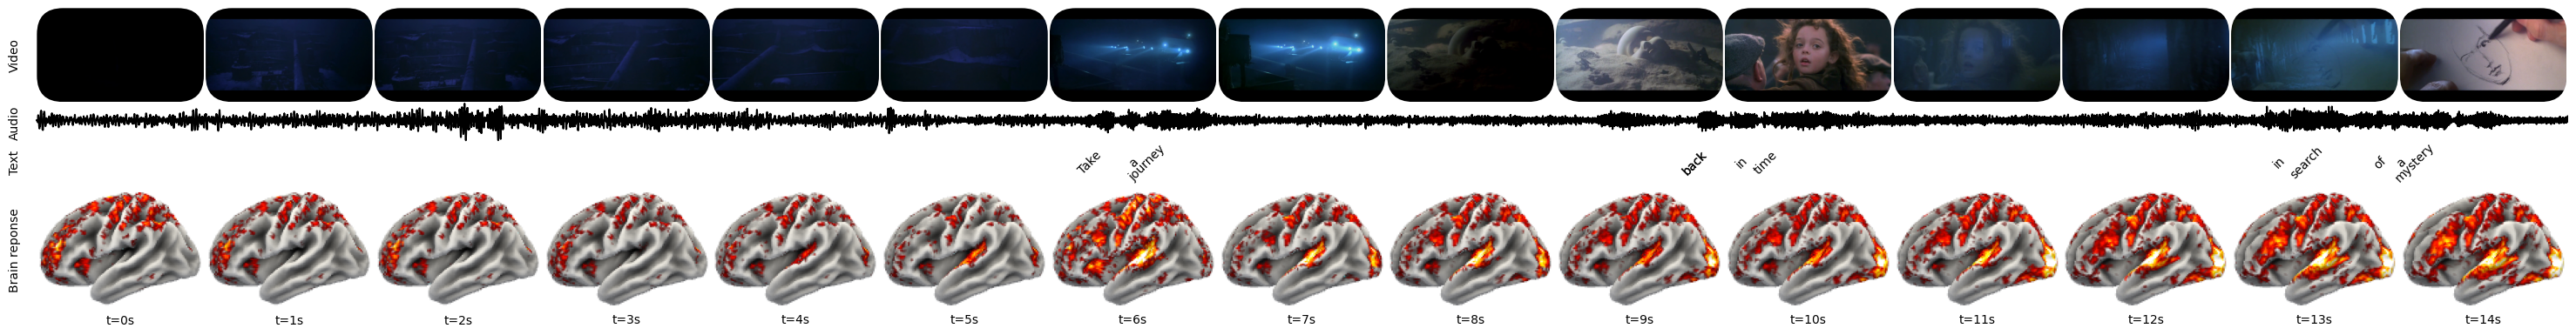

In [5]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)